# Volatility Management as Risk Avoidance: Evidence from Cross-Asset Time-Series Momentum

This notebook walks through the `src/tsmom` implementation of the research
question examined in the dissertation (`paper/dissertation.pdf`):

> Does portfolio-level volatility management genuinely improve cross-asset
> time-series momentum, or does it mainly produce a smoother, lower-exposure
> version of the same underlying strategy?

It reproduces the dissertation's methodology using the packaged, tested
implementation rather than the original one-off research notebook
(`original/original_research_notebook.ipynb`). See
[`docs/validation.md`](../docs/validation.md) for a full numerical
comparison against the dissertation's reported results.

**Data.** This notebook requires a local, licensed Bloomberg data pull
placed under `data/raw/` following the layout documented in
[`data/README.md`](../data/README.md). No market data is distributed with
this repository.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from tsmom import data, signals, volatility, strategies, performance, regressions, utils

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_DIR = data.DEFAULT_DATA_DIR
DATA_DIR

WindowsPath('C:/Users/milan/Documents/Github/tsmom-volatility-management/data/raw')

## 1. Data universe

19 futures contracts across four asset classes (commodities, equity
indices, government bonds, currencies), January 1990 onward. Daily
settlement prices are used only for volatility estimation; monthly
settlement prices drive the momentum signal and all strategy returns.

In [2]:
monthly_prices = data.load_monthly_prices(DATA_DIR / "monthly_settlement", start="1990")
daily_prices = data.load_daily_prices(DATA_DIR / "daily_settlement", start="1990")

returns = data.compute_returns(monthly_prices, clip=0.8)
daily_returns = data.compute_returns(daily_prices, clip=0.8)

print(f"{returns.shape[1]} contracts, {returns.dropna(how='all').index.min():%b-%Y} to {returns.dropna(how='all').index.max():%b-%Y}")

19 contracts, Feb-1990 to Jan-2026


In [3]:
summary_rows = []
for col in returns.columns:
    s = returns[col].dropna()
    if s.empty:
        continue
    summary_rows.append({
        "Contract": col,
        "Data start": s.index.min().strftime("%b-%y"),
        "Annualised mean": f"{s.mean() * 12 * 100:.2f}%",
        "Annualised volatility": f"{s.std() * (12 ** 0.5) * 100:.2f}%",
    })
asset_summary = pd.DataFrame(summary_rows).sort_values("Contract").reset_index(drop=True)
asset_summary

,Contract,Data start,Annualised mean,Annualised volatility
0,AD1_Curncy,Feb-90,0.36%,11.02%
1,BP1_Curncy,Feb-90,-0.14%,8.97%
2,CL1_Comdty,Feb-90,6.97%,33.44%
3,C_1_Comdty,Feb-90,5.44%,27.47%
4,EC1_Curncy,Jun-98,0.65%,9.27%
5,ES1,Oct-97,8.24%,15.44%
6,GC1_Comdty,Feb-90,7.94%,15.24%
7,G_1_Comdty,Feb-90,0.53%,8.01%
8,HG1_Comdty,Feb-90,8.03%,24.66%
9,JB1_Comdty,Feb-90,0.93%,3.86%


## 2. Signal and volatility estimation

The time-series momentum signal is the sign of each contract's trailing
12-month cumulative return. Ex-ante volatility is an EWMA of squared daily
returns (decay `delta = 60/61`, following Moskowitz, Ooi and Pedersen,
2012), sampled at month-end and lagged one period when used to size
positions.

In [4]:
signal = signals.momentum_signal(returns, lookback=12)

daily_vol = volatility.ewma_daily_volatility(daily_returns)
monthly_vol = volatility.month_end_volatility(daily_vol)

returns_a, signal_a, vol_a = utils.align_monthly(returns, signal, monthly_vol)
common_cols = returns_a.columns.intersection(signal_a.columns).intersection(vol_a.columns)
returns_a, signal_a, vol_a = returns_a[common_cols], signal_a[common_cols], vol_a[common_cols]
returns_a.shape

(433, 19)

## 3. TSMOM: cross-asset risk-normalised momentum

Each contract's position is sized to a 40% annualised volatility target
(`kappa = 0.40`), then averaged equally across the available universe.
Both the signal and the volatility estimate are lagged one month to avoid
look-ahead bias.

In [5]:
tsmom_asset = strategies.tsmom_asset_returns(returns_a, signal_a, vol_a, target_vol=0.40)
tsmom = strategies.tsmom_portfolio(tsmom_asset).dropna()
passive = strategies.passive_benchmark(returns_a).dropna()
tsmom.tail()

Date
2025-09-30    0.058601
2025-10-31    0.018962
2025-11-30    0.043741
2025-12-31    0.051936
2026-01-31    0.057805
Freq: ME, dtype: float64

## 4. VM-TSMOM: portfolio-level variance timing

**This is not an overlay on the TSMOM series above.** Following Moreira and
Muir (2017), VM-TSMOM scales a *separate, signal-only, equal-weight*
momentum portfolio (no per-asset volatility scaling) by the inverse of its
own lagged monthly realised variance, then rescales by a constant `c` so
its unconditional volatility matches that signal-only base. See the module
docstring in [`src/tsmom/strategies.py`](../src/tsmom/strategies.py) and
[`docs/validation.md`](../docs/validation.md) for why this distinction
matters for interpreting the comparison.

In [6]:
vm_result = strategies.build_vm_tsmom(returns_a, daily_returns, signal_a)
vm_tsmom = vm_result.returns

print(f"VM-TSMOM scale constant c = {vm_result.scale_constant:.6f}")
print(f"Median scaling weight = {vm_result.weight.median():.3f}")
vm_tsmom.tail()

VM-TSMOM scale constant c = 0.000013
Median scaling weight = 0.883


Date
2025-09-30    0.064215
2025-10-31    0.024603
2025-11-30    0.014842
2025-12-31    0.007264
2026-01-31    0.014993
Freq: ME, dtype: float64

## 5. Gross performance

Compare the passive benchmark, TSMOM, and VM-TSMOM before transaction
costs. Reference figures from the dissertation (Table 3): Passive
4.7%/8.4%/0.554/-30.2%, TSMOM 7.8%/14.3%/0.544/-35.4%,
VM-TSMOM 3.6%/6.7%/0.527/-19.5% (return / volatility / Sharpe / max drawdown).

In [7]:
gross = pd.concat([
    passive.rename("Passive"),
    tsmom.rename("TSMOM"),
    vm_tsmom.rename("VM-TSMOM"),
], axis=1).dropna()

performance.performance_summary(gross).round(4)

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Passive,0.0465,0.0839,0.5540,-0.3021
TSMOM,0.0775,0.1426,0.5437,-0.3537
VM-TSMOM,0.0355,0.0674,0.5268,-0.1947


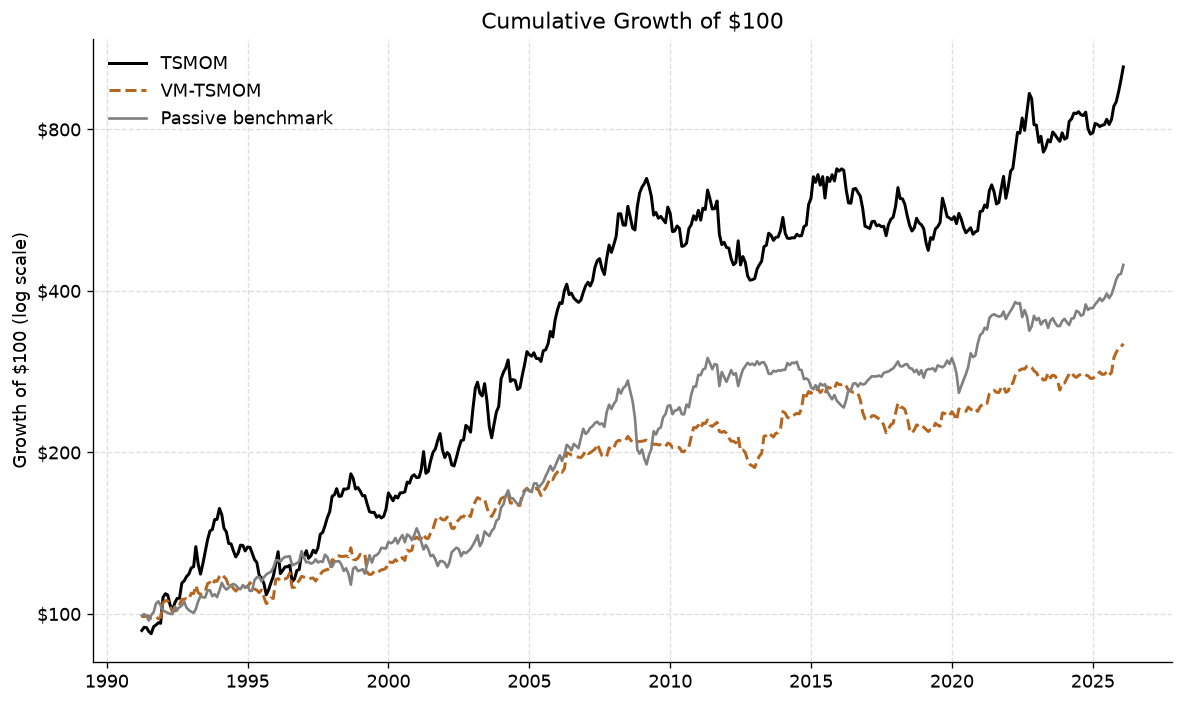

In [8]:
growth = performance.cumulative_growth(gross)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(growth.index, growth["TSMOM"], color="black", linewidth=1.8, label="TSMOM")
ax.plot(growth.index, growth["VM-TSMOM"], color="#b5651d", linewidth=1.8, linestyle="--", label="VM-TSMOM")
ax.plot(growth.index, growth["Passive"], color="gray", linewidth=1.6, label="Passive benchmark")
ax.set_yscale("log")
ax.set_yticks([100, 200, 400, 800])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${int(x)}"))
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Cumulative Growth of $100")
ax.set_ylabel("Growth of $100 (log scale)")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, which="major", linestyle="--", alpha=0.4)
fig.tight_layout()

## 6. Factor regressions

Monthly excess returns (over the 1-month T-bill) are regressed on MKT
(MSCI World), BOND (Bloomberg US Aggregate), GSCI (S&P GSCI), and the
Fama-French SMB/HML/UMD factors, with Newey-West HAC standard errors
(12 lags). Reference figures (Table 4): TSMOM alpha 0.0024 (p=0.344), UMD
loading 0.297; VM-TSMOM alpha -0.0004 (p=0.736), UMD loading 0.117.

In [9]:
FACTOR_DIR = DATA_DIR / "benchmarks"

ff = data.load_fama_french_factors(FACTOR_DIR / "F-F_Research_Data_Factors.csv")
umd = data.load_momentum_factor(FACTOR_DIR / "F-F_Momentum_Factor.csv")
msci = data.load_bloomberg_index_monthly_return(FACTOR_DIR / "MSCI_INDEX.csv").rename("MKT")
bond = data.load_bloomberg_index_monthly_return(FACTOR_DIR / "LBUSTRUU_monthly_TR.csv").rename("BOND")
gsci = data.load_bloomberg_index_monthly_return(FACTOR_DIR / "SPGSCITR_monthly_TR.csv").rename("GSCI")

factors = ff.join(umd, how="inner").join(msci, how="inner").join(bond, how="inner").join(gsci, how="inner")

tsmom_ms = utils.to_month_start(tsmom)
vm_tsmom_ms = utils.to_month_start(vm_tsmom)

reg_data = factors.join(tsmom_ms.rename("TSMOM"), how="inner").join(vm_tsmom_ms.rename("VM_TSMOM"), how="inner")
reg_data["TSMOM_excess"] = reg_data["TSMOM"] - reg_data["RF"]
reg_data["VM_TSMOM_excess"] = reg_data["VM_TSMOM"] - reg_data["RF"]

factor_cols = ["MKT", "BOND", "GSCI", "SMB", "HML", "UMD"]
model_tsmom = regressions.factor_regression(reg_data["TSMOM_excess"], reg_data[factor_cols])
model_vm = regressions.factor_regression(reg_data["VM_TSMOM_excess"], reg_data[factor_cols])

regressions.regression_summary_table({"TSMOM": model_tsmom, "VM-TSMOM": model_vm})

,TSMOM,VM-TSMOM
Variable,,
const,0.0024,-0.0004
,(0.0025),(0.0012)
MKT,-0.0006,0.0295
,(0.0783),(0.0267)
BOND,0.1336,0.1176
,(0.3440),(0.0970)
GSCI,0.0070,0.0066
,(0.0527),(0.0260)
SMB,-0.0915,-0.0295


## 7. Return-matched comparison

VM-TSMOM's lower drawdown in gross terms is partly mechanical: it runs at
roughly half the average return of TSMOM. Rescaling VM-TSMOM to match
TSMOM's mean return isolates the effect of variance timing from the effect
of running at lower average exposure. Reference: dissertation scale factor
2.183; return-matched VM-TSMOM 7.8%/14.7%/0.527/-38.9%.

In [10]:
rm_data = pd.concat([tsmom.rename("TSMOM"), vm_tsmom.rename("VM_TSMOM")], axis=1).dropna()
scale_factor = rm_data["TSMOM"].mean() / rm_data["VM_TSMOM"].mean()
rm_data["VM_TSMOM (return-matched)"] = rm_data["VM_TSMOM"] * scale_factor

print(f"Scale factor applied to VM-TSMOM: {scale_factor:.3f}")
performance.performance_summary(rm_data[["TSMOM", "VM_TSMOM (return-matched)"]]).round(4)

Scale factor applied to VM-TSMOM: 2.183


,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
TSMOM,0.0775,0.1426,0.5437,-0.3537
VM_TSMOM (return-matched),0.0775,0.1471,0.5268,-0.3891


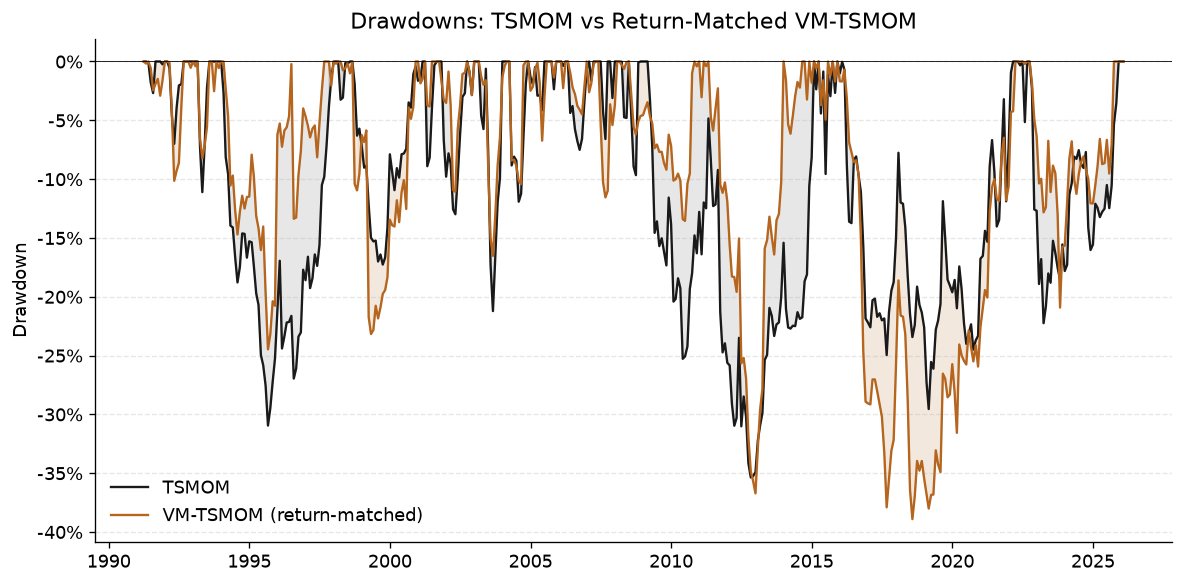

In [11]:
dd_tsmom = performance.drawdown(rm_data["TSMOM"])
dd_vm = performance.drawdown(rm_data["VM_TSMOM (return-matched)"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dd_tsmom.index, dd_tsmom.values, color="#1a1a1a", linewidth=1.4, label="TSMOM")
ax.plot(dd_vm.index, dd_vm.values, color="#b5651d", linewidth=1.4, label="VM-TSMOM (return-matched)")
ax.fill_between(dd_tsmom.index, dd_tsmom.values, dd_vm.values,
                where=(dd_vm.values < dd_tsmom.values), color="#b5651d", alpha=0.15)
ax.fill_between(dd_tsmom.index, dd_tsmom.values, dd_vm.values,
                where=(dd_tsmom.values < dd_vm.values), color="#1a1a1a", alpha=0.10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Drawdowns: TSMOM vs Return-Matched VM-TSMOM")
ax.set_ylabel("Drawdown")
ax.legend(loc="lower left", frameon=False)
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
ax.axhline(0, color="black", linewidth=0.5)
fig.tight_layout()

## 8. Transaction costs

Monthly one-way portfolio turnover, and performance net of 5bps and 10bps
per-unit-turnover costs. Reference: TSMOM average turnover 0.614,
VM-TSMOM 1.715 (Table 6); net-of-cost Sharpe ratios fall to 0.518/0.492
(TSMOM) and 0.375/0.222 (VM-TSMOM) at 5bps/10bps (Table 7).

In [12]:
weights = strategies.portfolio_weights(signal_a, vol_a, target_vol=0.40).loc[tsmom.index]
tsmom_turnover = performance.turnover(weights).dropna()

vm_weights = strategies.vm_portfolio_weights(weights, vm_result.weight)
vm_turnover = performance.turnover(vm_weights).dropna()

turnover_summary = pd.DataFrame({
    "Average monthly turnover": [tsmom_turnover.mean(), vm_turnover.mean()],
    "Median monthly turnover": [tsmom_turnover.median(), vm_turnover.median()],
}, index=["TSMOM", "VM-TSMOM"])
turnover_summary.round(3)

,Average monthly turnover,Median monthly turnover
TSMOM,0.612,0.521
VM-TSMOM,1.711,1.233


In [13]:
tc_data = pd.concat([
    tsmom.rename("TSMOM_gross"), vm_tsmom.rename("VM_TSMOM_gross"),
    tsmom_turnover.rename("TSMOM_turnover"), vm_turnover.rename("VM_TSMOM_turnover"),
], axis=1).dropna()

for bps in (5, 10):
    tc_data[f"TSMOM_net_{bps}bps"] = performance.apply_transaction_costs(tc_data["TSMOM_gross"], tc_data["TSMOM_turnover"], bps)
    tc_data[f"VM_TSMOM_net_{bps}bps"] = performance.apply_transaction_costs(tc_data["VM_TSMOM_gross"], tc_data["VM_TSMOM_turnover"], bps)

net_cols = ["TSMOM_net_5bps", "VM_TSMOM_net_5bps", "TSMOM_net_10bps", "VM_TSMOM_net_10bps"]
performance.performance_summary(tc_data[net_cols]).round(4)

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
TSMOM_net_5bps,0.0738,0.1425,0.5180,-0.3616
VM_TSMOM_net_5bps,0.0252,0.0672,0.3750,-0.2529
TSMOM_net_10bps,0.0701,0.1425,0.4923,-0.3694
VM_TSMOM_net_10bps,0.0149,0.0672,0.2220,-0.3122


## 9. Subperiod analysis: pre- vs post-2009

Splitting the sample at 2009 tests whether results are regime-dependent.
Reference (Table 8): TSMOM Sharpe falls from 0.821 (pre-2009) to 0.278
(post-2009); VM-TSMOM falls from 0.664 to 0.390; the passive benchmark is
comparatively stable (0.519 to 0.589).

In [14]:
pre = gross[gross.index < "2009-01-01"]
post = gross[gross.index >= "2009-01-01"]

print("Pre-2009:")
display(performance.performance_summary(pre).round(4))
print("\nPost-2009:")
display(performance.performance_summary(post).round(4))

Pre-2009:


,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Passive,0.0431,0.0831,0.5189,-0.2694
TSMOM,0.1124,0.1368,0.8213,-0.3096
VM-TSMOM,0.0437,0.0659,0.6636,-0.1184



Post-2009:


,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Passive,0.0500,0.0850,0.5887,-0.1918
TSMOM,0.0411,0.1479,0.2779,-0.3537
VM-TSMOM,0.0269,0.0690,0.3900,-0.1947


In [15]:
diff_gross, p_gross = performance.block_bootstrap_sharpe_test(gross["TSMOM"], gross["VM-TSMOM"], n_boot=10000, seed=42)
diff_10bps, p_10bps = performance.block_bootstrap_sharpe_test(
    tc_data["TSMOM_net_10bps"].dropna(), tc_data["VM_TSMOM_net_10bps"].dropna(), n_boot=10000, seed=42
)

pd.DataFrame({
    "Comparison": ["TSMOM vs VM-TSMOM (gross)", "TSMOM vs VM-TSMOM (net of 10bps)"],
    "Sharpe difference": [diff_gross, diff_10bps],
    "p-value": [p_gross, p_10bps],
})

,Comparison,Sharpe difference,p-value
0,TSMOM vs VM-TSMOM (gross),0.016924,0.8762
1,TSMOM vs VM-TSMOM (net of 10bps),0.270273,0.0153


## 10. Conclusions

- TSMOM earns a higher gross return than the passive benchmark (7.8% vs
  4.7%), but at proportionally higher volatility, leaving its Sharpe ratio
  (0.544) close to the benchmark's (0.554).
- VM-TSMOM's smoother gross return profile is mostly a lower-exposure
  effect: once its returns are matched to TSMOM's, its Sharpe ratio and
  maximum drawdown are no better than TSMOM's, and its drawdown is worse.
- VM-TSMOM's higher turnover (roughly 2.8x TSMOM's) makes it far more
  sensitive to transaction costs: its Sharpe ratio falls to 0.222 at 10bps,
  versus 0.492 for TSMOM.
- Neither strategy produces a statistically significant factor-model alpha
  in this specification.
- TSMOM's edge is concentrated pre-2009; post-2009 performance weakens
  materially for both strategies, while the passive benchmark holds up.

Taken together, this is consistent with the dissertation's interpretation:
in this cross-asset setting, portfolio-level volatility management behaves
more like a form of risk avoidance than a genuine efficiency improvement,
because the base TSMOM strategy already performs cross-asset risk
normalisation at the position level. See
[`docs/validation.md`](../docs/validation.md) for the full numerical
comparison against the dissertation, and Section 6 of the dissertation for
the complete discussion and limitations.